# Customer Churn — Exploratory Data Analysis

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 attributes).

Goal of this notebook: understand who churns and why, so that the feature engineering in `features.py` is driven by evidence. Every number in the README's *Key Business Insights* table is computed here.

Run `python ingestion_db.py` first — it downloads the data and loads it into SQLite.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ingestion_db import create_connection

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)

engine = create_connection()
df = pd.read_sql_query("SELECT * FROM telecom_data", engine)
engine.dispose()
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data quality

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
# TotalCharges is stored as text. Which rows fail to convert?
tc = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Non-numeric TotalCharges:", tc.isna().sum())
df.loc[tc.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Non-numeric TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


All 11 blank `TotalCharges` rows have `tenure = 0`: they are brand-new customers who have not been billed yet. So the correct fill value is **0**, not the mean or median. `clean_raw_data()` in `features.py` does exactly this.

In [4]:
df["TotalCharges"] = tc.fillna(0.0)
df["Churn"] = (df["Churn"] == "Yes").astype(int)
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())
print("Missing values:", df.isna().sum().sum())

Duplicate customer IDs: 0
Missing values: 0


## 2. Target: class imbalance

Churn rate: 26.5%  (1869 of 7043 customers)


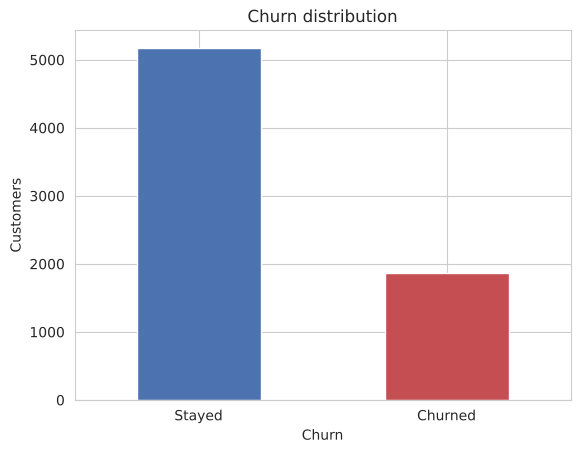

In [5]:
rate = df["Churn"].mean()
print(f"Churn rate: {rate:.1%}  ({df['Churn'].sum()} of {len(df)} customers)")
ax = df["Churn"].map({0: "Stayed", 1: "Churned"}).value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"], rot=0)
ax.set_title("Churn distribution"); ax.set_ylabel("Customers")
plt.show()

Only ~26.5% of customers churn. A model that always predicts "no churn" would already be 73.5% accurate, so **accuracy is a misleading metric** here. This is why the project:
- evaluates with **ROC-AUC, Precision, Recall and F1** for the churn class, and
- uses **SMOTE** (inside the training pipeline) to balance the classes during training.

## 3. Numeric features

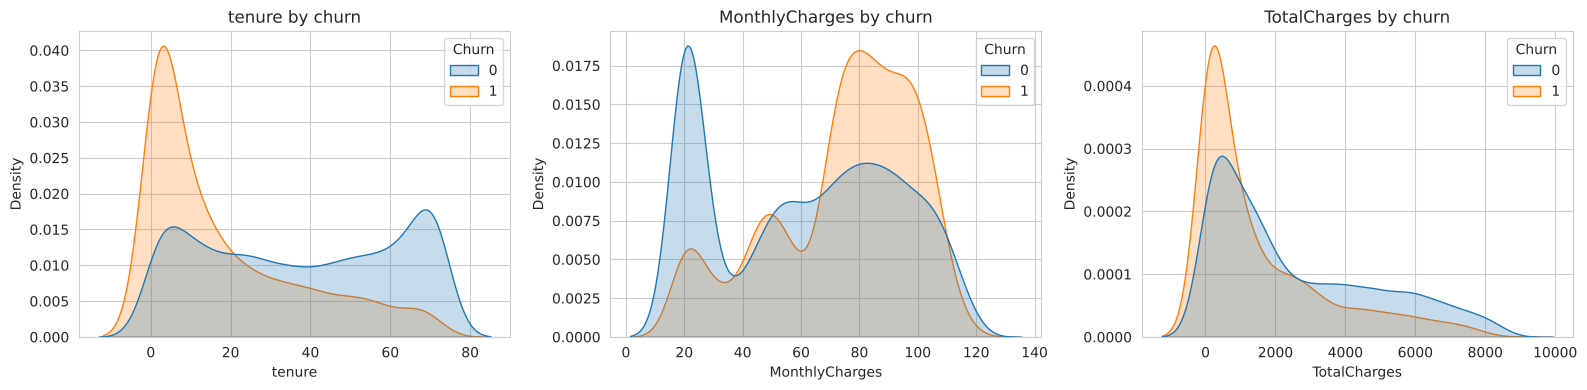

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,38.0,64.425,1679.525
1,10.0,79.650,703.550


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=col, hue="Churn", common_norm=False, fill=True, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout(); plt.show()
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].median()

- Churners have much **shorter tenure** (median ~10 months vs ~38).
- Churners pay **higher monthly charges**.
- Lower `TotalCharges` for churners is mostly a side-effect of short tenure (TotalCharges ≈ tenure × MonthlyCharges).

## 4. Churn rate by segment

In [7]:
def churn_rate(col):
    return (df.groupby(col)["Churn"].agg(["mean", "count"])
              .rename(columns={"mean": "churn_rate", "count": "customers"})
              .sort_values("churn_rate", ascending=False)
              .style.format({"churn_rate": "{:.1%}"}))

churn_rate("Contract")

,churn_rate,customers
Contract,,
Month-to-month,42.7%,3875
One year,11.3%,1473
Two year,2.8%,1695


In [8]:
df["tenure_segment"] = pd.cut(df["tenure"], bins=[-1, 6, 12, 24, 48, 100],
                              labels=["0-6m", "6m-1yr", "1-2yr", "2-4yr", "4+yr"])
churn_rate("tenure_segment")

,churn_rate,customers
tenure_segment,,
0-6m,52.9%,1481
6m-1yr,35.9%,705
1-2yr,28.7%,1024
2-4yr,20.4%,1594
4+yr,9.5%,2239


In [9]:
churn_rate("PaymentMethod")

,churn_rate,customers
PaymentMethod,,
Electronic check,45.3%,2365
Mailed check,19.1%,1612
Bank transfer (automatic),16.7%,1544
Credit card (automatic),15.2%,1522


In [10]:
churn_rate("InternetService")

,churn_rate,customers
InternetService,,
Fiber optic,41.9%,3096
DSL,19.0%,2421
No,7.4%,1526


In [11]:
churn_rate("TechSupport")

,churn_rate,customers
TechSupport,,
No,41.6%,3473
Yes,15.2%,2044
No internet service,7.4%,1526


In [12]:
churn_rate("SeniorCitizen")

,churn_rate,customers
SeniorCitizen,,
1,41.7%,1142
0,23.6%,5901


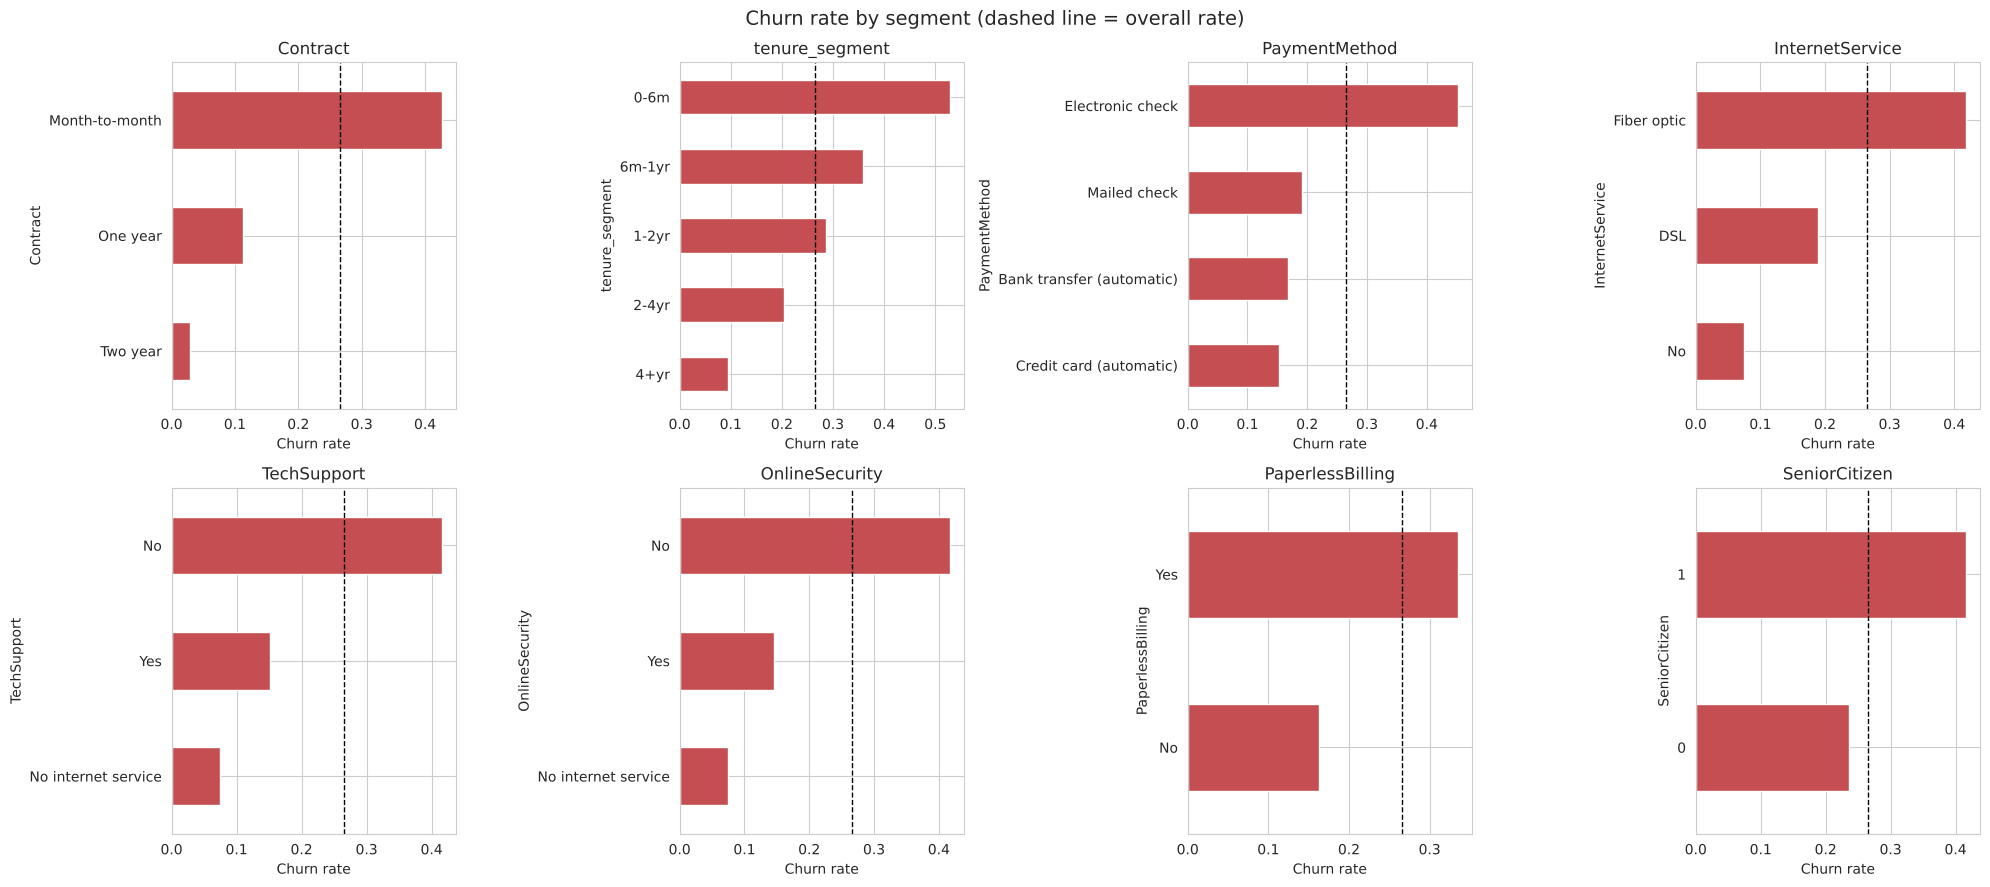

In [13]:
cat_cols = ["Contract", "tenure_segment", "PaymentMethod", "InternetService",
            "TechSupport", "OnlineSecurity", "PaperlessBilling", "SeniorCitizen"]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flat, cat_cols):
    r = df.groupby(col, observed=True)["Churn"].mean().sort_values()
    r.plot(kind="barh", ax=ax, color="#C44E52")
    ax.axvline(rate, ls="--", c="k", lw=1)
    ax.set_title(col); ax.set_xlabel("Churn rate")
plt.suptitle("Churn rate by segment (dashed line = overall rate)", fontsize=14)
plt.tight_layout(); plt.show()

## 5. Add-on services and household

In [14]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
df["service_bundle_score"] = (df[service_cols] == "Yes").sum(axis=1)
df["single_customer"] = ((df["Partner"] == "No") & (df["Dependents"] == "No")).astype(int)
display(churn_rate("service_bundle_score"))
display(churn_rate("single_customer"))

,churn_rate,customers
service_bundle_score,,
1,38.9%,1467
0,29.8%,2793
2,23.8%,1372
3,12.4%,941
4,5.3%,470


,churn_rate,customers
single_customer,,
1,34.2%,3280
0,19.8%,3763


Among customers with internet service, every extra add-on lowers churn: 38.9% with one add-on down to 5.3% with all four. (The 0-add-on group looks lower at 29.8% only because it includes customers with no internet service, who churn at 7.4%.) Customers with no partner and no dependents churn at 34.2% vs 19.8% for the rest. These become the engineered features `service_bundle_score` and `single_customer`.

## 6. Correlation with churn

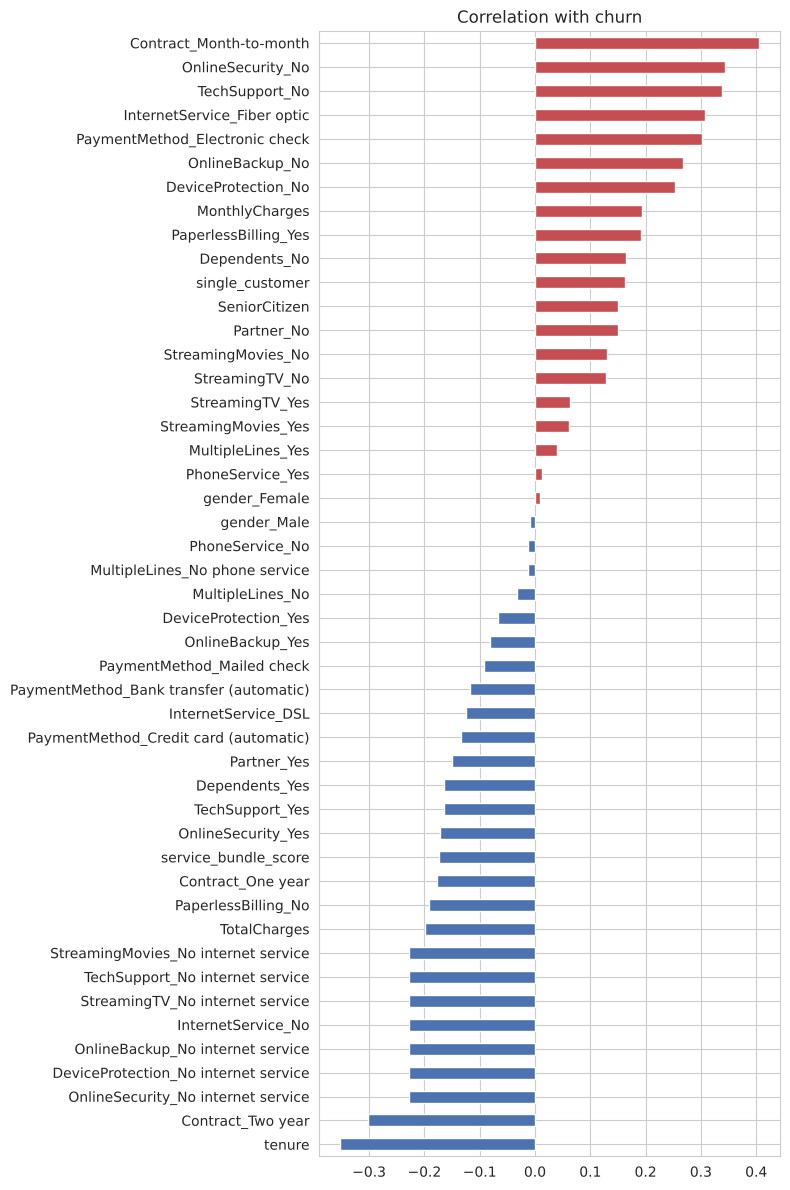

In [15]:
enc = pd.get_dummies(df.drop(columns=["customerID", "tenure_segment"]), drop_first=False, dtype=int)
corr = enc.corr()["Churn"].drop("Churn").sort_values()
plt.figure(figsize=(8, 12))
corr.plot(kind="barh", color=np.where(corr > 0, "#C44E52", "#4C72B0"))
plt.title("Correlation with churn"); plt.tight_layout(); plt.show()

## 7. Summary → feature engineering decisions

| EDA finding | Churn rate | Engineered feature (`features.py`) |
|---|---|---|
| Month-to-month contract | 42.7% vs 2.8% (two-year) | `is_month_to_month`, `has_long_contract` |
| Tenure 0–6 months | 52.9% vs 9.5% (4+ yrs) | `tenure_segment` |
| Electronic check payment | 45.3% vs 15–19% (others) | `high_risk_payment` |
| Fiber optic internet | 41.9% vs 19.0% (DSL) | one-hot `InternetService` |
| No tech support | 41.6% vs 15.2% | `service_bundle_score` |
| Senior citizens | 41.7% vs 23.6% | `SeniorCitizen` |
| High monthly bill | higher for churners | `high_monthly_charges`, `charges_per_tenure` |
| No partner and no dependents | higher churn | `single_customer` |

**Highest-risk profile:** new customers on month-to-month contracts, paying high monthly bills by electronic check, without add-on support services.

Next step: `python train.py` (or the `churn_prediction.ipynb` notebook) builds the full pipeline: feature engineering → one-hot encoding → SMOTE → model-based feature selection → Random Forest / XGBoost / LightGBM.